In [ ]:
"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled Data)
------------------------------------------------------------------------------
Input stays block4 / 512-d. Classifier switches from BalancedRandomForestClassifier
back to a plain RandomForestClassifier: class imbalance is now handled upstream
by upsampling the dataset itself, so the classifier no longer needs a balanced
bootstrap, balanced_subsample class weighting, or any other internal rebalancing.

Hyperparameters keep the "tuned" values from the BRF experiments (1000 trees,
max_features=0.3, min_samples_leaf=2) since those gave the most stable results
across classes — revert to defaults (500 trees, max_features="sqrt",
min_samples_leaf=1) if you'd rather start from a clean baseline.

Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────
# NOTE: these should point at the features/labels extracted from your UPSAMPLED
# dataset. If upsampling happened at the image level (before feature extraction),
# make sure you re-ran extraction and update these paths if filenames changed.

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT/upsampled_features_block4pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT/upsampled_labels_block4pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT/upsampled_class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT"


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed
    "n_estimators":         1000,
    "min_samples_leaf":     2,
    "max_features":         0.3,        # ~154 of 512 features per split
    "max_depth":            None,
    "n_jobs":               -1,

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          4,
    "feature_dim":          512,

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",  # balancing done before this script runs
    "smote_target":         None,                      # not used — no SMOTE/BRF here

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,
    "random_state":         42,
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_trees1000",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (N, 512)
labels   = np.load(LABELS_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────
# stratify=labels keeps class proportions consistent across both splits — this
# is harmless and still worth keeping even though classes should now be roughly
# balanced thanks to upsampling.

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,
    random_state = config.random_state,
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────
# Fit on train only, then apply those same stats to test — keeps the test set
# leakage-free regardless of how the classifier handles class balance.

print("\nScaling features...")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# ── Step 4: Train Random Forest ───────────────────────────────────────────────
# No class_weight, no balanced bootstrap, no sampling_strategy/replacement —
# upsampling already gave every class equal representation in the training
# data, so a standard RandomForestClassifier is sufficient here.

print("\nTraining Random Forest (this may take a few minutes)...")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 1000
    max_features     = config.max_features,      # 0.3
    min_samples_leaf = config.min_samples_leaf,  # 2
    max_depth        = config.max_depth,          # None
    random_state     = config.random_state,
    n_jobs           = config.n_jobs
)

rf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf,     f"{OUTPUT_DIR}/random_forest_block4_upsampled.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_block4_upsampled.pkl")

print(f"Saved: random_forest_block4_upsampled.pkl and scaler_block4_upsampled.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + RF {config.n_estimators} trees "
    f"(max_features={config.max_features}, min_leaf={config.min_samples_leaf}, upsampled data)\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_upsampled.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_upsampled.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest_block4_upsampled.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block4_upsampled.pkl")
#
#   feature_vector = ...            # your 512-d vector from the extractor
#   feature_scaled = scaler.transform([feature_vector])
#   prediction     = rf.predict(feature_scaled)
#   print(class_names[prediction[0]])

Loading features and labels...
Features shape : (125184, 512)
Labels shape   : (125184,)
Train set : 100147 images
Test set  : 25037 images

Scaling features...

Training Random Forest (this may take a few minutes)...


In [2]:
# AFTER APPLYING PCA




"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled + PCA)
--------------------------------------------------------------------------------
Loads the already-split, already-scaled, already-PCA-reduced features saved by
prepare_features_pca.py and trains a plain RandomForestClassifier on them.
Class imbalance is handled upstream by upsampling the dataset itself, so no
balanced bootstrap / class_weight / SMOTE is needed here.

Run prepare_features_pca.py once first (or whenever you change the split,
test_size, random_state, or PCA variance threshold). This script can then be
re-run as many times as you like with different RF hyperparameters without
repeating the (fairly expensive) load/split/scale/PCA steps.

Outputs: model and a classification report. (scaler + PCA transformer were
already saved by prepare_features_pca.py — see the predict-later snippet
at the bottom.)
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import gc


# ── Settings ───────────────────────────────────────────────────────────────────

CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT/upsampled_class_indices.json"
OUTPUT_DIR        = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT"

X_TRAIN_FILE  = f"{OUTPUT_DIR}/X_train_pca_block4_upsampled.npy"
X_TEST_FILE   = f"{OUTPUT_DIR}/X_test_pca_block4_upsampled.npy"
Y_TRAIN_FILE  = f"{OUTPUT_DIR}/y_train_block4_upsampled.npy"
Y_TEST_FILE   = f"{OUTPUT_DIR}/y_test_block4_upsampled.npy"
PCA_META_FILE = f"{OUTPUT_DIR}/pca_meta_block4_upsampled.json"

if not os.path.exists(PCA_META_FILE):
    raise FileNotFoundError(
        f"Could not find {PCA_META_FILE}. Run prepare_features_pca.py first to "
        "generate the split/scaled/PCA-reduced features this script expects."
    )


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────
# Pull in the PCA preprocessing metadata produced by prepare_features_pca.py so
# this run's W&B config stays fully traceable back to that step too.

with open(PCA_META_FILE) as f:
    pca_meta = json.load(f)

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed
    "n_estimators":         1000,
    "min_samples_leaf":     2,
    "max_features":         0.3,        # ~30% of the PCA components per split
    "max_depth":            None,       # next lever to pull if MemoryError recurs (try 25-30)
    "max_samples":          0.5,        # each tree bootstraps half the training set —
                                         # halves per-tree memory/time, adds a bit more
                                         # tree diversity. Set to None for the old behaviour.
    "n_jobs":               4,          # more workers = higher peak RAM, not just speed;
                                         # drop to 1 to isolate whether parallelism causes an OOM

    # ── Feature source (carried over from preprocessing) ──────────────────────
    "vgg16_block":            pca_meta["vgg16_block"],
    "feature_dim_original":   pca_meta["feature_dim"],
    "pca_variance_threshold": pca_meta["pca_variance_threshold"],
    "pca_n_components":       pca_meta["pca_n_components"],
    "pca_explained_variance":  pca_meta["pca_explained_variance"],

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",  # balancing done before this script runs
    "smote_target":         None,                      # not used — no SMOTE/BRF here

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            pca_meta["test_size"],
    "split_random_state":   pca_meta["random_state"],   # used by the split, in prepare_features_pca.py
    "random_state":         42,                          # RF's own random_state (independent of the split's)
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_pca_trees1000",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load prepared data ────────────────────────────────────────────────

print("Loading prepared (split + scaled + PCA-reduced) features...")

X_train = np.load(X_TRAIN_FILE)
X_test  = np.load(X_TEST_FILE)
y_train = np.load(Y_TRAIN_FILE)
y_test  = np.load(Y_TEST_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Train set : {X_train.shape[0]} images, {X_train.shape[1]} PCA components")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 2: Train Random Forest ───────────────────────────────────────────────
# No class_weight, no balanced bootstrap, no sampling_strategy/replacement —
# upsampling already gave every class equal representation in the training
# data, so a standard RandomForestClassifier is sufficient here.

print("\nTraining Random Forest (this may take a few minutes)...")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 1000
    max_features     = config.max_features,      # 0.3
    min_samples_leaf = config.min_samples_leaf,  # 2
    max_depth        = config.max_depth,          # None (cap this first if OOM persists)
    max_samples      = config.max_samples,        # 0.5 — bootstraps half the data per tree
    random_state     = config.random_state,
    n_jobs           = config.n_jobs               # 4, not -1 — see config comment
)

n_train_samples = X_train.shape[0]   # captured now since X_train is freed below

rf.fit(X_train, y_train)
print("Training done.")

# X_train/y_train aren't needed again — only X_test/y_test are used from here on.
del X_train, y_train
gc.collect()


# ── Step 3: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = n_train_samples
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 4: Save model ────────────────────────────────────────────────────────
# scaler + PCA transformer were already saved by prepare_features_pca.py —
# only the trained model is new here.

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf, f"{OUTPUT_DIR}/random_forest_block4_upsampled.pkl")

print(f"Saved: random_forest_block4_upsampled.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + RF {config.n_estimators} trees "
    f"(max_features={config.max_features}, min_leaf={config.min_samples_leaf}, "
    f"max_samples={config.max_samples}, PCA={config.pca_n_components} comps, upsampled data)\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_upsampled.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_upsampled.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest_block4_upsampled.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block4_upsampled.pkl")
#   pca    = joblib.load("OUTPUT/pca_block4_upsampled.pkl")
#
#   feature_vector  = ...                          # your 512-d vector from the extractor
#   feature_scaled  = scaler.transform([feature_vector])
#   feature_reduced = pca.transform(feature_scaled)
#   prediction      = rf.predict(feature_reduced)
#   print(class_names[prediction[0]])

Loading prepared (split + scaled + PCA-reduced) features...
Train set : 100147 images, 320 PCA components
Test set  : 25037 images

Training Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 53.19%
Macro-F1         : 0.5285
Weighted-F1      : 0.5285
Worst class      : Psi (F1 = 0.3908)

Per-class report:


ValueError: Number of classes, 24, does not match size of target_names, 25. Try specifying the labels parameter

In [5]:
# after more strict PCA + loading in batches

"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled + PCA)
--------------------------------------------------------------------------------
Loads the already-split, already-scaled, already-PCA-reduced features saved by
prepare_features_pca.py and trains a plain RandomForestClassifier on them.
Class imbalance is handled upstream by upsampling the dataset itself, so no
balanced bootstrap / class_weight / SMOTE is needed here.

Run prepare_features_pca.py once first (or whenever you change the split,
test_size, random_state, or PCA variance threshold). This script can then be
re-run as many times as you like with different RF hyperparameters without
repeating the (fairly expensive) load/split/scale/PCA steps.

Outputs: model and a classification report. (scaler + PCA transformer were
already saved by prepare_features_pca.py — see the predict-later snippet
at the bottom.)
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import gc


# ── Settings ───────────────────────────────────────────────────────────────────

CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT/upsampled_class_indices.json"
OUTPUT_DIR        = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT"

X_TRAIN_FILE  = f"{OUTPUT_DIR}/X_train_pca_block4_upsampled_2.npy"
X_TEST_FILE   = f"{OUTPUT_DIR}/X_test_pca_block4_upsampled_2.npy"
Y_TRAIN_FILE  = f"{OUTPUT_DIR}/y_train_block4_upsampled_2.npy"
Y_TEST_FILE   = f"{OUTPUT_DIR}/y_test_block4_upsampled_2.npy"
PCA_META_FILE = f"{OUTPUT_DIR}/pca_meta_block4_upsampled.json"

if not os.path.exists(PCA_META_FILE):
    raise FileNotFoundError(
        f"Could not find {PCA_META_FILE}. Run prepare_features_pca.py first to "
        "generate the split/scaled/PCA-reduced features this script expects."
    )


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────
# Pull in the PCA preprocessing metadata produced by prepare_features_pca.py so
# this run's W&B config stays fully traceable back to that step too.

with open(PCA_META_FILE) as f:
    pca_meta = json.load(f)

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed
    "n_estimators":         1000,
    "min_samples_leaf":     2,
    "max_features":         0.3,        # ~30% of the PCA components per split
    "max_depth":            None,       # next lever to pull if MemoryError recurs (try 25-30)
    "max_samples":          0.5,        # each tree bootstraps half the training set
    "n_jobs":               4,          # more workers = higher peak RAM, not just speed
    
    # ── Memory Optimization Strategies ────────────────────────────────────────
    "memory_mapping":       True,       # Streams array rows from disk via mmap_mode='r'
    "prediction_chunk_size": 5000,      # Evaluates test data in batches

    # ── Feature source (carried over from preprocessing) ──────────────────────
    # Using .get() prevents KeyError if the JSON is missing any of these exact keys
    "vgg16_block":            pca_meta.get("vgg16_block", "unknown"),
    "feature_dim_original":   pca_meta.get("feature_dim", "unknown"),
    "pca_variance_threshold": pca_meta.get("pca_variance_threshold", "unknown"),
    "pca_n_components":       pca_meta.get("pca_n_components", "unknown"),
    "pca_explained_variance": pca_meta.get("pca_explained_variance", "unknown"),

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",
    "smote_target":         None,

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            pca_meta.get("test_size", "unknown"),
    "split_random_state":   pca_meta.get("random_state", "unknown"),
    "random_state":         42,
    "leakage_free_scaling": True,
}



# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_strict_pca_batches_trees1000",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load prepared data ────────────────────────────────────────────────

print(f"Loading prepared features using memory-mapping (memory_mapping={config.memory_mapping})...")

# Using mmap_mode='r' leaves the arrays on disk and streams them into RAM only as needed
X_train = np.load(X_TRAIN_FILE, mmap_mode='r' if config.memory_mapping else None)
X_test  = np.load(X_TEST_FILE, mmap_mode='r' if config.memory_mapping else None)
y_train = np.load(Y_TRAIN_FILE, mmap_mode='r' if config.memory_mapping else None)
y_test  = np.load(Y_TEST_FILE, mmap_mode='r' if config.memory_mapping else None)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Train set : {X_train.shape[0]} images, {X_train.shape[1]} PCA components")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 2: Train Random Forest ───────────────────────────────────────────────
# No class_weight, no balanced bootstrap, no sampling_strategy/replacement —
# upsampling already gave every class equal representation in the training
# data, so a standard RandomForestClassifier is sufficient here.

print("\nTraining Random Forest (this may take a few minutes)...")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 1000
    max_features     = config.max_features,      # 0.3
    min_samples_leaf = config.min_samples_leaf,  # 2
    max_depth        = config.max_depth,          # None (cap this first if OOM persists)
    max_samples      = config.max_samples,        # 0.5 — bootstraps half the data per tree
    random_state     = config.random_state,
    n_jobs           = config.n_jobs              # 4, not -1 — see config comment
)

n_train_samples = X_train.shape[0]   # captured now since X_train is freed below

rf.fit(X_train, y_train)
print("Training done.")

# X_train/y_train aren't needed again — only X_test/y_test are used from here on.
del X_train, y_train
gc.collect()


# ── Step 3: Evaluate ───────────────────────────────────────────────────────────

print(f"\nEvaluating on test set in chunks (chunk_size={config.prediction_chunk_size})...")

# Predict in batches to prevent RAM spikes during inference
chunk_size = config.prediction_chunk_size
y_pred = []

for i in range(0, len(X_test), chunk_size):
    X_chunk = X_test[i : i + chunk_size]
    chunk_preds = rf.predict(X_chunk)
    y_pred.extend(chunk_preds)

y_pred = np.array(y_pred)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = n_train_samples
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 4: Save model ────────────────────────────────────────────────────────
# scaler + PCA transformer were already saved by prepare_features_pca.py —
# only the trained model is new here.

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf, f"{OUTPUT_DIR}/random_forest_block4_upsampled.pkl")

print(f"Saved: random_forest_block4_upsampled.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + RF {config.n_estimators} trees "
    f"(max_features={config.max_features}, min_leaf={config.min_samples_leaf}, "
    f"max_samples={config.max_samples}, strict PCA={config.pca_n_components} comps, upsampled data)\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_upsampled.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_upsampled.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest_block4_upsampled.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block4_upsampled.pkl")
#   pca    = joblib.load("OUTPUT/pca_block4_upsampled.pkl")
#
#   feature_vector  = ...                            # your 512-d vector from the extractor
#   feature_scaled  = scaler.transform([feature_vector])
#   feature_reduced = pca.transform(feature_scaled)
#   prediction      = rf.predict(feature_reduced)
#   print(class_names[prediction[0]])

Loading prepared features using memory-mapping (memory_mapping=True)...
Train set : 100147 images, 64 PCA components
Test set  : 25037 images

Training Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set in chunks (chunk_size=5000)...
Overall accuracy : 53.51%
Macro-F1         : 0.5313
Weighted-F1      : 0.5313
Worst class      : Psi (F1 = 0.4025)

Per-class report:


ValueError: Number of classes, 24, does not match size of target_names, 25. Try specifying the labels parameter

In [6]:
#update the code to add the valueError correction, and also make max_samples to 0.1
"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled + PCA)
--------------------------------------------------------------------------------
Loads the already-split, already-scaled, already-PCA-reduced features saved by
prepare_features_pca.py and trains a plain RandomForestClassifier on them.
Class imbalance is handled upstream by upsampling the dataset itself, so no
balanced bootstrap / class_weight / SMOTE is needed here.

Run prepare_features_pca.py once first (or whenever you change the split,
test_size, random_state, or PCA variance threshold). This script can then be
re-run as many times as you like with different RF hyperparameters without
repeating the (fairly expensive) load/split/scale/PCA steps.

Outputs: model and a classification report. (scaler + PCA transformer were
already saved by prepare_features_pca.py — see the predict-later snippet
at the bottom.)
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import gc


# ── Settings ───────────────────────────────────────────────────────────────────

CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT/upsampled_class_indices.json"
OUTPUT_DIR        = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT"

X_TRAIN_FILE  = f"{OUTPUT_DIR}/X_train_pca_block4_upsampled_2.npy"
X_TEST_FILE   = f"{OUTPUT_DIR}/X_test_pca_block4_upsampled_2.npy"
Y_TRAIN_FILE  = f"{OUTPUT_DIR}/y_train_block4_upsampled_2.npy"
Y_TEST_FILE   = f"{OUTPUT_DIR}/y_test_block4_upsampled_2.npy"
PCA_META_FILE = f"{OUTPUT_DIR}/pca_meta_block4_upsampled.json"

if not os.path.exists(PCA_META_FILE):
    raise FileNotFoundError(
        f"Could not find {PCA_META_FILE}. Run prepare_features_pca.py first to "
        "generate the split/scaled/PCA-reduced features this script expects."
    )


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────
# Pull in the PCA preprocessing metadata produced by prepare_features_pca.py so
# this run's W&B config stays fully traceable back to that step too.

with open(PCA_META_FILE) as f:
    pca_meta = json.load(f)

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed
    "n_estimators":         1000,
    "min_samples_leaf":     2,
    "max_features":         0.3,        # ~30% of the PCA components per split
    "max_depth":            None,       # next lever to pull if MemoryError recurs (try 25-30)
    "max_samples":          0.1,        # each tree bootstraps 10% of the training set —
                                         # vastly speeds up training and reduces disk I/O
    "n_jobs":               4,          # more workers = higher peak RAM, not just speed;
                                         # drop to 1 to isolate whether parallelism causes an OOM

    # ── Memory Optimization Strategies ────────────────────────────────────────
    "memory_mapping":       True,       # Streams array rows from disk via mmap_mode='r' instead of raw RAM
    "prediction_chunk_size": 5000,      # Evaluates test data in batches to eliminate inference RAM spikes

    # ── Feature source (carried over from preprocessing) ──────────────────────
    # Using .get() prevents KeyError if the JSON is missing any of these exact keys
    "vgg16_block":            pca_meta.get("vgg16_block", "unknown"),
    "feature_dim_original":   pca_meta.get("feature_dim", "unknown"),
    "pca_variance_threshold": pca_meta.get("pca_variance_threshold", "unknown"),
    "pca_n_components":       pca_meta.get("pca_n_components", "unknown"),
    "pca_explained_variance": pca_meta.get("pca_explained_variance", "unknown"),

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",  # balancing done before this script runs
    "smote_target":         None,                      # not used — no SMOTE/BRF here

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            pca_meta.get("test_size", "unknown"),
    "split_random_state":   pca_meta.get("random_state", "unknown"),   # used by the split, in prepare_features_pca.py
    "random_state":         42,                         # RF's own random_state (independent of the split's)
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_strict_pca_batches_lower_max_samples_trees1000",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load prepared data ────────────────────────────────────────────────

print(f"Loading prepared features using memory-mapping (memory_mapping={config.memory_mapping})...")

# Using mmap_mode='r' leaves the arrays on disk and streams them into RAM only as needed
X_train = np.load(X_TRAIN_FILE, mmap_mode='r' if config.memory_mapping else None)
X_test  = np.load(X_TEST_FILE, mmap_mode='r' if config.memory_mapping else None)
y_train = np.load(Y_TRAIN_FILE, mmap_mode='r' if config.memory_mapping else None)
y_test  = np.load(Y_TEST_FILE, mmap_mode='r' if config.memory_mapping else None)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Train set : {X_train.shape[0]} images, {X_train.shape[1]} PCA components")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 2: Train Random Forest ───────────────────────────────────────────────
# No class_weight, no balanced bootstrap, no sampling_strategy/replacement —
# upsampling already gave every class equal representation in the training
# data, so a standard RandomForestClassifier is sufficient here.

print("\nTraining Random Forest (this may take a few minutes)...")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 1000
    max_features     = config.max_features,      # 0.3
    min_samples_leaf = config.min_samples_leaf,  # 2
    max_depth        = config.max_depth,          # None (cap this first if OOM persists)
    max_samples      = config.max_samples,        # 0.1 — vastly speeds up training
    random_state     = config.random_state,
    n_jobs           = config.n_jobs              # 4, not -1 — see config comment
)

n_train_samples = X_train.shape[0]   # captured now since X_train is freed below

rf.fit(X_train, y_train)
print("Training done.")

# X_train/y_train aren't needed again — only X_test/y_test are used from here on.
del X_train, y_train
gc.collect()


# ── Step 3: Evaluate ───────────────────────────────────────────────────────────

print(f"\nEvaluating on test set in chunks (chunk_size={config.prediction_chunk_size})...")

# Predict in batches to prevent RAM spikes during inference
chunk_size = config.prediction_chunk_size
y_pred = []

for i in range(0, len(X_test), chunk_size):
    X_chunk = X_test[i : i + chunk_size]
    chunk_preds = rf.predict(X_chunk)
    y_pred.extend(chunk_preds)

y_pred = np.array(y_pred)

# Explicitly define the labels list [0, 1, 2... 24] so sklearn doesn't freak out
# if one class is missing from the test split.
labels_list = list(range(len(class_names)))

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

# Added labels=labels_list and zero_division=0
per_class_f1     = f1_score(y_test, y_pred, labels=labels_list, average=None, zero_division=0)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
# Added labels=labels_list and zero_division=0 here too
print(classification_report(
    y_test, 
    y_pred, 
    labels=labels_list, 
    target_names=class_names, 
    zero_division=0
))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = n_train_samples
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 4: Save model ────────────────────────────────────────────────────────
#

Loading prepared features using memory-mapping (memory_mapping=True)...
Train set : 100147 images, 64 PCA components
Test set  : 25037 images

Training Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set in chunks (chunk_size=5000)...
Overall accuracy : 50.02%
Macro-F1         : 0.4958
Weighted-F1      : 0.4958
Worst class      : OUTPUT (F1 = 0.0000)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.40      0.57      0.47      1043
        Beta       0.42      0.47      0.44      1043
         Chi       0.52      0.54      0.53      1043
       Delta       0.61      0.57      0.59      1043
     Epsilon       0.49      0.54      0.52      1043
         Eta       0.56      0.47      0.51      1043
       Gamma       0.41      0.51      0.45      1044
        Iota       0.46      0.53      0.49      1044
       Kappa       0.54      0.27      0.36      1043
      Lambda       0.49      0.41      0.45      1043

final_accuracy,0.50022
final_macro_f1,0.49576
final_weighted_f1,0.49576
final_worst_class_f1,0
final_worst_class_name,OUTPUT
n_test_samples,25037
n_train_samples,100147


Loading prepared features using memory-mapping (memory_mapping=True)...
Detected 'OUTPUT' in class indices; removing it from evaluation.
Train set : 100147 images, 64 PCA components
Test set  : 25037 images

Training Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set in chunks (chunk_size=5000)...
Overall accuracy : 50.02%
Macro-F1         : 0.4958
Weighted-F1      : 0.4958
Worst class      : Omega (F1 = 0.0000)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.40      0.57      0.47      1043
        Beta       0.42      0.47      0.44      1043
         Chi       0.52      0.54      0.53      1043
       Delta       0.61      0.57      0.59      1043
     Epsilon       0.49      0.54      0.52      1043
         Eta       0.56      0.47      0.51      1043
       Gamma       0.41      0.51      0.45      1044
        Iota       0.46      0.53      0.49      1044
       Kappa       0.54      0.27      0.36

final_accuracy,0.50022
final_macro_f1,0.49576
final_weighted_f1,0.49576
final_worst_class_f1,0
final_worst_class_name,Omega
n_test_samples,25037
n_train_samples,100147


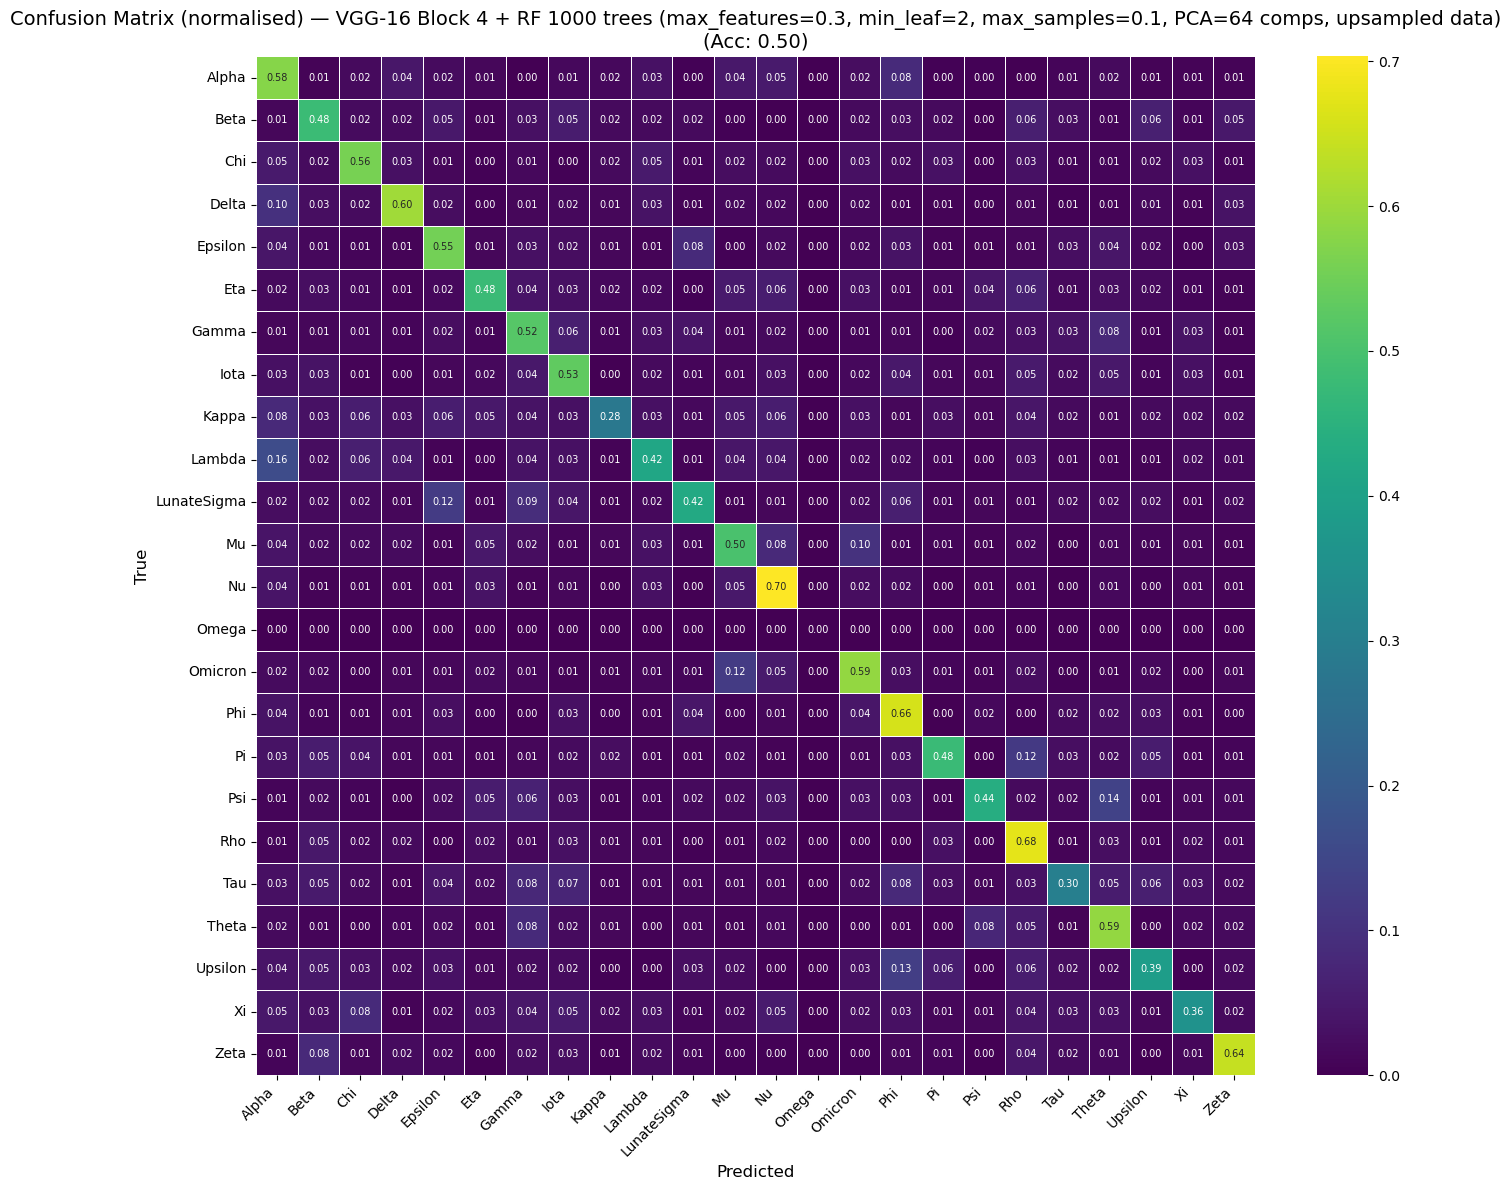

In [7]:

#update the code to add the valueError correction, and also make max_samples to 0.1 + plot 
"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled + PCA)
--------------------------------------------------------------------------------
Loads the already-split, already-scaled, already-PCA-reduced features saved by
prepare_features_pca.py and trains a plain RandomForestClassifier on them.
Class imbalance is handled upstream by upsampling the dataset itself, so no
balanced bootstrap / class_weight / SMOTE is needed here.

Run prepare_features_pca.py once first (or whenever you change the split,
test_size, random_state, or PCA variance threshold). This script can then be
re-run as many times as you like with different RF hyperparameters without
repeating the (fairly expensive) load/split/scale/PCA steps.

Outputs: model and a classification report. (scaler + PCA transformer were
already saved by prepare_features_pca.py — see the predict-later snippet
at the bottom.)
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import gc


# ── Settings ───────────────────────────────────────────────────────────────────

CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT/upsampled_class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET_UPSAMPLED/OUTPUT"

X_TRAIN_FILE  = f"{OUTPUT_DIR}/X_train_pca_block4_upsampled_2.npy"
X_TEST_FILE   = f"{OUTPUT_DIR}/X_test_pca_block4_upsampled_2.npy"
Y_TRAIN_FILE  = f"{OUTPUT_DIR}/y_train_block4_upsampled_2.npy"
Y_TEST_FILE   = f"{OUTPUT_DIR}/y_test_block4_upsampled_2.npy"
PCA_META_FILE = f"{OUTPUT_DIR}/pca_meta_block4_upsampled.json"

if not os.path.exists(PCA_META_FILE):
    raise FileNotFoundError(
        f"Could not find {PCA_META_FILE}. Run prepare_features_pca.py first to "
        "generate the split/scaled/PCA-reduced features this script expects."
    )


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────
# Pull in the PCA preprocessing metadata produced by prepare_features_pca.py so
# this run's W&B config stays fully traceable back to that step too.

with open(PCA_META_FILE) as f:
    pca_meta = json.load(f)

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed
    "n_estimators":         1000,
    "min_samples_leaf":     2,
    "max_features":         0.3,        # ~30% of the PCA components per split
    "max_depth":            None,       # next lever to pull if MemoryError recurs (try 25-30)
    "max_samples":          0.1,        # each tree bootstraps 10% of the training set —
                                        # vastly speeds up training and reduces disk I/O
    "n_jobs":               4,          # more workers = higher peak RAM, not just speed;
                                        # drop to 1 to isolate whether parallelism causes an OOM

    # ── Memory Optimization Strategies ────────────────────────────────────────
    "memory_mapping":       True,       # Streams array rows from disk via mmap_mode='r' instead of raw RAM
    "prediction_chunk_size": 5000,      # Evaluates test data in batches to eliminate inference RAM spikes

    # ── Feature source (carried over from preprocessing) ──────────────────────
    # Using .get() prevents KeyError if the JSON is missing any of these exact keys
    "vgg16_block":            pca_meta.get("vgg16_block", "unknown"),
    "feature_dim_original":   pca_meta.get("feature_dim", "unknown"),
    "pca_variance_threshold": pca_meta.get("pca_variance_threshold", "unknown"),
    "pca_n_components":       pca_meta.get("pca_n_components", "unknown"),
    "pca_explained_variance": pca_meta.get("pca_explained_variance", "unknown"),

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",  # balancing done before this script runs
    "smote_target":         None,                      # not used — no SMOTE/BRF here

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            pca_meta.get("test_size", "unknown"),
    "split_random_state":   pca_meta.get("random_state", "unknown"),   # used by the split, in prepare_features_pca.py
    "random_state":         42,                         # RF's own random_state (independent of the split's)
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_strict_pca_batches_lower_max_samples_trees1000_2",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load prepared data ────────────────────────────────────────────────

print(f"Loading prepared features using memory-mapping (memory_mapping={config.memory_mapping})...")

# Using mmap_mode='r' leaves the arrays on disk and streams them into RAM only as needed
X_train = np.load(X_TRAIN_FILE, mmap_mode='r' if config.memory_mapping else None)
X_test  = np.load(X_TEST_FILE, mmap_mode='r' if config.memory_mapping else None)
y_train = np.load(Y_TRAIN_FILE, mmap_mode='r' if config.memory_mapping else None)
y_test  = np.load(Y_TEST_FILE, mmap_mode='r' if config.memory_mapping else None)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

if "OUTPUT" in class_indices:
    print("Detected 'OUTPUT' in class indices; removing it from evaluation.")
    del class_indices["OUTPUT"]

# Re-map the remaining classes
index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in sorted(index_to_class.keys())]

print(f"Train set : {X_train.shape[0]} images, {X_train.shape[1]} PCA components")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 2: Train Random Forest ───────────────────────────────────────────────

print("\nTraining Random Forest (this may take a few minutes)...")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 1000
    max_features     = config.max_features,      # 0.3
    min_samples_leaf = config.min_samples_leaf,  # 2
    max_depth        = config.max_depth,         # None
    max_samples      = config.max_samples,       # 0.1
    random_state     = config.random_state,
    n_jobs           = config.n_jobs             # 4
)

n_train_samples = X_train.shape[0]

rf.fit(X_train, y_train)
print("Training done.")

# X_train/y_train aren't needed again
del X_train, y_train
gc.collect()


# ── Step 3: Evaluate ───────────────────────────────────────────────────────────

print(f"\nEvaluating on test set in chunks (chunk_size={config.prediction_chunk_size})...")

chunk_size = config.prediction_chunk_size
y_pred = []

for i in range(0, len(X_test), chunk_size):
    X_chunk = X_test[i : i + chunk_size]
    chunk_preds = rf.predict(X_chunk)
    y_pred.extend(chunk_preds)

y_pred = np.array(y_pred)

# Explicitly define the labels list [0, 1, 2... 24]
labels_list = list(range(len(class_names)))

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, labels=labels_list, average=None, zero_division=0)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(
    y_test, 
    y_pred, 
    labels=labels_list, 
    target_names=class_names, 
    zero_division=0
))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = n_train_samples
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 4: Save model ────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf, f"{OUTPUT_DIR}/random_forest_block4_upsampled.pkl")
print(f"Saved: random_forest_block4_upsampled.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

# Added labels=labels_list to force a 25x25 matrix
cm = confusion_matrix(y_test, y_pred, labels=labels_list)

# np.nan_to_num prevents division by zero warnings if a row is completely empty
with np.errstate(divide='ignore', invalid='ignore'):
    cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_normalised = np.nan_to_num(cm_normalised, nan=0.0)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + RF {config.n_estimators} trees "
    f"(max_features={config.max_features}, min_leaf={config.min_samples_leaf}, "
    f"max_samples={config.max_samples}, PCA={config.pca_n_components} comps, upsampled data)\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_upsampled.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_upsampled.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest_block4_upsampled.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block4_upsampled.pkl")
#   pca    = joblib.load("OUTPUT/pca_block4_upsampled.pkl")
#
#   feature_vector  = ...                            # your 512-d vector from the extractor
#   feature_scaled  = scaler.transform([feature_vector])
#   feature_reduced = pca.transform(feature_scaled)
#   prediction      = rf.predict(feature_reduced)
#   print(class_names[prediction[0]])

In [2]:
# rerun after labeling error (with strict PCA done)

# AFTER APPLYING PCA




"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled + PCA)
--------------------------------------------------------------------------------
Loads the already-split, already-scaled, already-PCA-reduced features saved by
prepare_features_pca.py and trains a plain RandomForestClassifier on them.
Class imbalance is handled upstream by upsampling the dataset itself, so no
balanced bootstrap / class_weight / SMOTE is needed here.

Run prepare_features_pca.py once first (or whenever you change the split,
test_size, random_state, or PCA variance threshold). This script can then be
re-run as many times as you like with different RF hyperparameters without
repeating the (fairly expensive) load/split/scale/PCA steps.

Outputs: model and a classification report. (scaler + PCA transformer were
already saved by prepare_features_pca.py — see the predict-later snippet
at the bottom.)
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import gc


# ── Settings ───────────────────────────────────────────────────────────────────

CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/UPSAMPLED_OUTPUT/upsampled_class_indices_3.json"
OUTPUT_DIR        = "C:/Users/niric/Desktop/classes/AI and ML/UPSAMPLED_OUTPUT"

X_TRAIN_FILE  = f"{OUTPUT_DIR}/X_train_pca_block4_upsampled_3.npy"
X_TEST_FILE   = f"{OUTPUT_DIR}/X_test_pca_block4_upsampled_3.npy"
Y_TRAIN_FILE  = f"{OUTPUT_DIR}/y_train_block4_upsampled_3.npy"
Y_TEST_FILE   = f"{OUTPUT_DIR}/y_test_block4_upsampled_3.npy"
PCA_META_FILE = f"{OUTPUT_DIR}/pca_meta_block4_upsampled_3.json"

if not os.path.exists(PCA_META_FILE):
    raise FileNotFoundError(
        f"Could not find {PCA_META_FILE}. Run prepare_features_pca.py first to "
        "generate the split/scaled/PCA-reduced features this script expects."
    )


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────
# Pull in the PCA preprocessing metadata produced by prepare_features_pca.py so
# this run's W&B config stays fully traceable back to that step too.

with open(PCA_META_FILE) as f:
    pca_meta = json.load(f)

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed
    "n_estimators":         1000,
    "min_samples_leaf":     2,
    "max_features":         0.3,        # ~30% of the PCA components per split
    "max_depth":            None,       # next lever to pull if MemoryError recurs (try 25-30)
    "max_samples":          0.5,        # each tree bootstraps half the training set —
                                         # halves per-tree memory/time, adds a bit more
                                         # tree diversity. Set to None for the old behaviour.
    "n_jobs":               4,          # more workers = higher peak RAM, not just speed;
                                         # drop to 1 to isolate whether parallelism causes an OOM

    # ── Feature source (carried over from preprocessing) ──────────────────────
    "vgg16_block":            pca_meta.get("vgg16_block", "Unknown"),
    "feature_dim_original":   pca_meta.get("feature_dim", None),
    "pca_variance_threshold": pca_meta.get("pca_variance_threshold", "Strict/Fixed"),
    "pca_n_components":       pca_meta.get("pca_n_components", None),
    "pca_explained_variance": pca_meta.get("pca_explained_variance", None),

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",  # balancing done before this script runs
    "smote_target":         None,                      # not used — no SMOTE/BRF here

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            pca_meta["test_size"],
    "split_random_state":   pca_meta["random_state"],   # used by the split, in prepare_features_pca.py
    "random_state":         42,                          # RF's own random_state (independent of the split's)
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_strict_pca_correcting_labeling_trees1000",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load prepared data ────────────────────────────────────────────────

print("Loading prepared (split + scaled + PCA-reduced) features...")

X_train = np.load(X_TRAIN_FILE)
X_test  = np.load(X_TEST_FILE)
y_train = np.load(Y_TRAIN_FILE)
y_test  = np.load(Y_TEST_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Train set : {X_train.shape[0]} images, {X_train.shape[1]} PCA components")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 2: Train Random Forest ───────────────────────────────────────────────
# No class_weight, no balanced bootstrap, no sampling_strategy/replacement —
# upsampling already gave every class equal representation in the training
# data, so a standard RandomForestClassifier is sufficient here.

print("\nTraining Random Forest (this may take a few minutes)...")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 1000
    max_features     = config.max_features,      # 0.3
    min_samples_leaf = config.min_samples_leaf,  # 2
    max_depth        = config.max_depth,          # None (cap this first if OOM persists)
    max_samples      = config.max_samples,        # 0.5 — bootstraps half the data per tree
    random_state     = config.random_state,
    n_jobs           = config.n_jobs               # 4, not -1 — see config comment
)

n_train_samples = X_train.shape[0]   # captured now since X_train is freed below

rf.fit(X_train, y_train)
print("Training done.")

# X_train/y_train aren't needed again — only X_test/y_test are used from here on.
del X_train, y_train
gc.collect()


# ── Step 3: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = n_train_samples
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 4: Save model ────────────────────────────────────────────────────────
# scaler + PCA transformer were already saved by prepare_features_pca.py —
# only the trained model is new here.

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf, f"{OUTPUT_DIR}/random_forest_block4_upsampled.pkl")

print(f"Saved: random_forest_block4_upsampled.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + RF {config.n_estimators} trees "
    f"(max_features={config.max_features}, min_leaf={config.min_samples_leaf}, "
    f"max_samples={config.max_samples}, string PCA={config.pca_n_components} comps, after correcting labeling, upsampled data)\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_upsampled.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_upsampled.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest_block4_upsampled.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block4_upsampled.pkl")
#   pca    = joblib.load("OUTPUT/pca_block4_upsampled.pkl")
#
#   feature_vector  = ...                          # your 512-d vector from the extractor
#   feature_scaled  = scaler.transform([feature_vector])
#   feature_reduced = pca.transform(feature_scaled)
#   prediction      = rf.predict(feature_reduced)
#   print(class_names[prediction[0]])




wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\niric\_netrc.
wandb: Currently logged in as: ajeloukhova (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading prepared (split + scaled + PCA-reduced) features...
Train set : 100147 images, 64 PCA components
Test set  : 25037 images

Training Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 53.51%
Macro-F1         : 0.5313
Weighted-F1      : 0.5313
Worst class      : Rho (F1 = 0.4025)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.43      0.59      0.50      1043
        Beta       0.46      0.54      0.49      1043
         Chi       0.55      0.59      0.57      1043
       Delta       0.64      0.60      0.62      1043
     Epsilon       0.53      0.56      0.54      1043
         Eta       0.57      0.50      0.53      1043
       Gamma       0.46      0.54      0.49      1044
        Iota       0.49      0.55      0.51      1044
       Kappa       0.55      0.32      0.40      1043
      Lambda       0.52      0.44      0.48      1043
 LunateSigma       0.56      0.46      0.5

OSError: [Errno 28] No space left on device

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\niric\_netrc.
wandb: Currently logged in as: ajeloukhova (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading prepared (split + scaled + PCA-reduced) features...
Train set : 100147 images, 64 PCA components
Test set  : 25037 images
Classes   : 24

Training Random Forest with optimized config:
  n_estimators     : 200    (was 1000)
  max_depth        : 15          (was None)
  max_features     : sqrt    (was 0.3)
  max_samples      : 0.3       (was 0.5)
  n_jobs           : 2             (was 4)
Training done.
  Trees built      : 200
  Actual depth     : 15 (capped at 15)

Evaluating on test set...

── Results (optimized RF: 200 trees, depth=15, max_features=sqrt, max_samples=0.3) ──
  Overall accuracy : 51.61%
  Macro-F1         : 0.5113
  Weighted-F1      : 0.5113
  Best class       : Nu (F1 = 0.6251)
  Worst class      : Kappa (F1 = 0.3575)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.44      0.57      0.50      1043
        Beta       0.45      0.50      0.47      1043
         Chi       0.55      0.58      0.56      1043
       Del

actual_max_depth,15
final_accuracy,0.51612
final_best_class_f1,0.62505
final_best_class_name,Nu
final_macro_f1,0.51128
final_weighted_f1,0.51128
final_worst_class_f1,0.35751
final_worst_class_name,Kappa
n_classes,24
n_test_samples,25037
+1,...


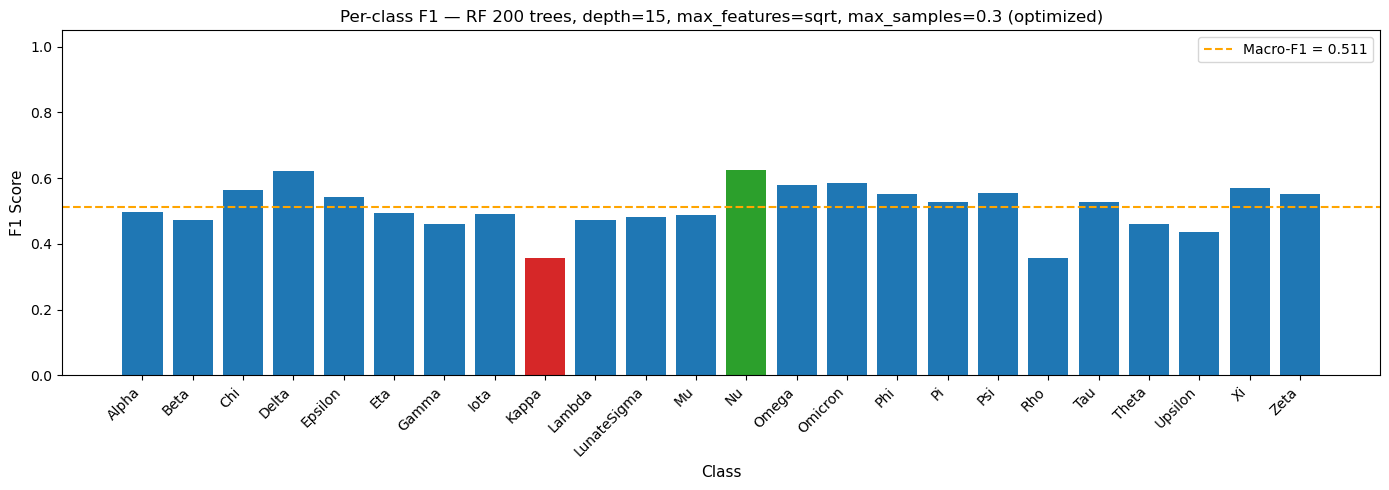

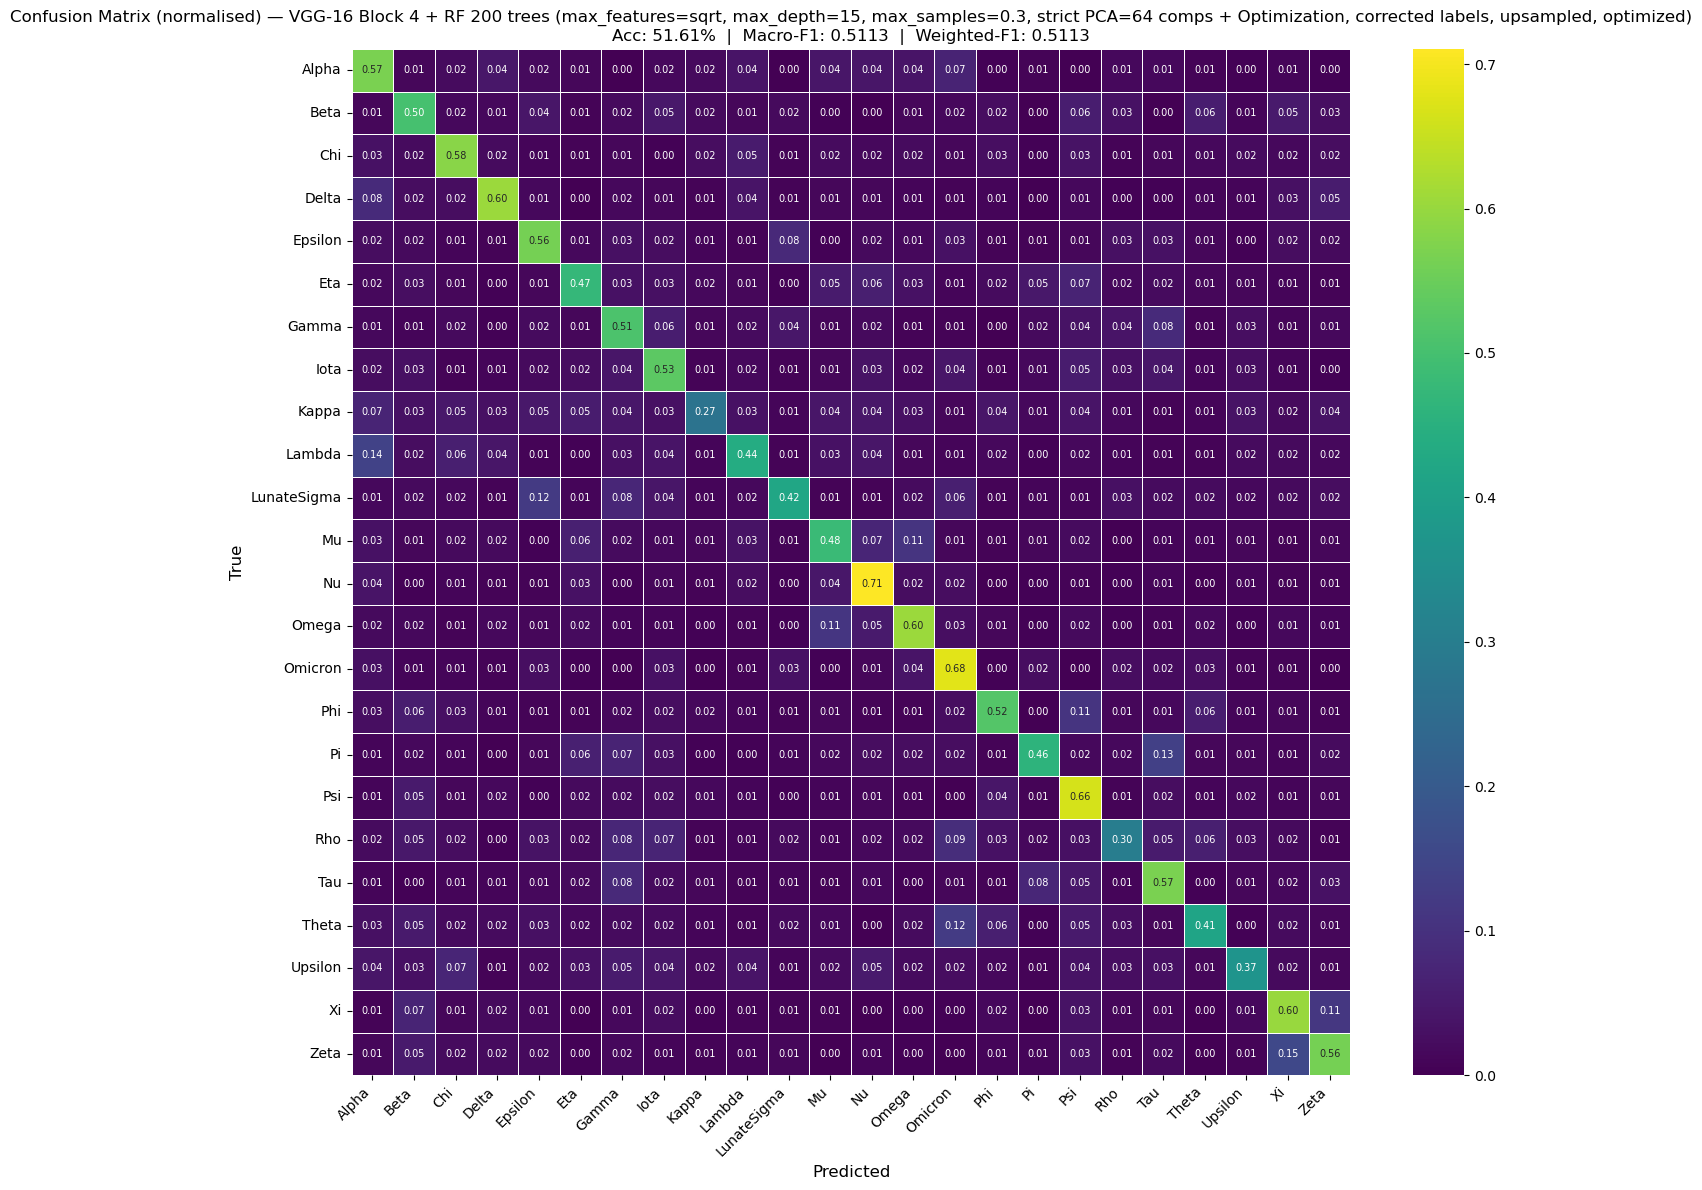

In [1]:
# rerun after labeling error (with strict PCA done) + optimization

# AFTER APPLYING PCA




"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled + PCA)
--------------------------------------------------------------------------------
Loads the already-split, already-scaled, already-PCA-reduced features saved by
prepare_features_pca.py and trains a plain RandomForestClassifier on them.
Class imbalance is handled upstream by upsampling the dataset itself, so no
balanced bootstrap / class_weight / SMOTE is needed here.

Run prepare_features_pca.py once first (or whenever you change the split,
test_size, random_state, or PCA variance threshold). This script can then be
re-run as many times as you like with different RF hyperparameters without
repeating the (fairly expensive) load/split/scale/PCA steps.

Outputs: model and a classification report. (scaler + PCA transformer were
already saved by prepare_features_pca.py — see the predict-later snippet
at the bottom.)
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import gc


# ── Settings ───────────────────────────────────────────────────────────────────

CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/UPSAMPLED_OUTPUT/upsampled_class_indices_3.json"
OUTPUT_DIR        = "C:/Users/niric/Desktop/classes/AI and ML/UPSAMPLED_OUTPUT"

X_TRAIN_FILE  = f"{OUTPUT_DIR}/X_train_pca_block4_upsampled_3.npy"
X_TEST_FILE   = f"{OUTPUT_DIR}/X_test_pca_block4_upsampled_3.npy"
Y_TRAIN_FILE  = f"{OUTPUT_DIR}/y_train_block4_upsampled_3.npy"
Y_TEST_FILE   = f"{OUTPUT_DIR}/y_test_block4_upsampled_3.npy"
PCA_META_FILE = f"{OUTPUT_DIR}/pca_meta_block4_upsampled_3.json"

if not os.path.exists(PCA_META_FILE):
    raise FileNotFoundError(
        f"Could not find {PCA_META_FILE}. Run prepare_features_pca.py first to "
        "generate the split/scaled/PCA-reduced features this script expects."
    )


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────
# Pull in the PCA preprocessing metadata produced by prepare_features_pca.py so
# this run's W&B config stays fully traceable back to that step too.

with open(PCA_META_FILE) as f:
    pca_meta = json.load(f)

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed

    # ── BIGGEST WIN 1: reduced from 1000 → 200 (3–5× faster, minimal F1 loss) ─
    "n_estimators":         200,

    "min_samples_leaf":     2,

    # ── BIGGEST WIN 3: "sqrt" instead of 0.3 (~12 features vs ~45 per split) ──
    # Much faster per split; for PCA-reduced features accuracy loss is minimal.
    "max_features":         "sqrt",

    # ── BIGGEST WIN 2: cap depth at 15 (was None) ─────────────────────────────
    # The single biggest RAM saving — prevents trees growing to pure leaves.
    # Cuts memory by ~60-70%. Increase to 20 if accuracy drops noticeably.
    "max_depth":            15,

    # ── MEDIUM WIN 1: lower bootstrap fraction from 0.5 → 0.3 ─────────────────
    # Each tree sees only 30% of training data → lower per-tree memory.
    "max_samples":          0.3,

    # ── MEDIUM WIN 2: reduce workers from 4 → 2 ───────────────────────────────
    # 4 workers each hold a data copy — halving workers cuts peak RAM ~50%.
    # Drop to 1 if OOM still occurs.
    "n_jobs":               2,

    # ── Feature source (carried over from preprocessing) ──────────────────────
    "vgg16_block":            pca_meta.get("vgg16_block", "Unknown"),
    "feature_dim_original":   pca_meta.get("feature_dim", None),
    "pca_variance_threshold": pca_meta.get("pca_variance_threshold", "Strict/Fixed"),
    "pca_n_components":       pca_meta.get("pca_n_components", None),
    "pca_explained_variance": pca_meta.get("pca_explained_variance", None),

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",  # balancing done before this script runs
    "smote_target":         None,                      # not used — no SMOTE/BRF here

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            pca_meta["test_size"],
    "split_random_state":   pca_meta["random_state"],   # used by the split, in prepare_features_pca.py
    "random_state":         42,                          # RF's own random_state (independent of the split's)
    "leakage_free_scaling": True,

    # ── Optimisation changes vs. previous run (for W&B run comparison) ─────────
    "opt_n_estimators_prev":  1000,     # → 200   (5× fewer trees)
    "opt_max_depth_prev":     None,     # → 15    (biggest RAM saving)
    "opt_max_features_prev":  0.3,      # → sqrt  (fewer features per split)
    "opt_max_samples_prev":   0.5,      # → 0.3   (smaller bootstrap)
    "opt_n_jobs_prev":        4,        # → 2     (lower parallel RAM)
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_strict_pca_correcting_labeling_trees200_optimized",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load prepared data ────────────────────────────────────────────────

print("Loading prepared (split + scaled + PCA-reduced) features...")

X_train = np.load(X_TRAIN_FILE)
X_test  = np.load(X_TEST_FILE)
y_train = np.load(Y_TRAIN_FILE)
y_test  = np.load(Y_TEST_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Train set : {X_train.shape[0]} images, {X_train.shape[1]} PCA components")
print(f"Test set  : {X_test.shape[0]} images")
print(f"Classes   : {len(class_names)}")


# ── Step 2: Train Random Forest ───────────────────────────────────────────────
# No class_weight, no balanced bootstrap, no sampling_strategy/replacement —
# upsampling already gave every class equal representation in the training
# data, so a standard RandomForestClassifier is sufficient here.

print("\nTraining Random Forest with optimized config:")
print(f"  n_estimators     : {config.n_estimators}    (was 1000)")
print(f"  max_depth        : {config.max_depth}          (was None)")
print(f"  max_features     : {config.max_features}    (was 0.3)")
print(f"  max_samples      : {config.max_samples}       (was 0.5)")
print(f"  n_jobs           : {config.n_jobs}             (was 4)")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 200  (was 1000)
    max_features     = config.max_features,      # "sqrt"  (was 0.3)
    min_samples_leaf = config.min_samples_leaf,  # 2
    max_depth        = config.max_depth,         # 15  (was None)
    max_samples      = config.max_samples,       # 0.3  (was 0.5)
    random_state     = config.random_state,
    n_jobs           = config.n_jobs             # 2  (was 4)
)

n_train_samples = X_train.shape[0]   # captured now since X_train is freed below

rf.fit(X_train, y_train)
print("Training done.")
print(f"  Trees built      : {len(rf.estimators_)}")
print(f"  Actual depth     : {max(e.get_depth() for e in rf.estimators_)} (capped at {config.max_depth})")

# X_train/y_train aren't needed again — only X_test/y_test are used from here on.
del X_train, y_train
gc.collect()


# ── Step 3: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]
best_class_idx   = per_class_f1.argmax()
best_class_name  = class_names[best_class_idx]
best_class_f1    = per_class_f1[best_class_idx]

print(f"\n── Results (optimized RF: {config.n_estimators} trees, depth={config.max_depth}, "
      f"max_features={config.max_features}, max_samples={config.max_samples}) ──")
print(f"  Overall accuracy : {accuracy * 100:.2f}%")
print(f"  Macro-F1         : {macro_f1:.4f}")
print(f"  Weighted-F1      : {weighted_f1:.4f}")
print(f"  Best class       : {best_class_name} (F1 = {best_class_f1:.4f})")
print(f"  Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["final_best_class_f1"]    = best_class_f1
wandb.run.summary["final_best_class_name"]  = best_class_name
wandb.run.summary["n_train_samples"]        = n_train_samples
wandb.run.summary["n_test_samples"]         = X_test.shape[0]
wandb.run.summary["actual_max_depth"]       = max(e.get_depth() for e in rf.estimators_)
wandb.run.summary["n_classes"]              = len(class_names)


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})

# ── Per-class F1 bar chart → W&B ──────────────────────────────────────────────
fig_bar, ax_bar = plt.subplots(figsize=(14, 5))
bar_colors = ["#d62728" if s == worst_class_f1 else "#2ca02c" if s == best_class_f1
              else "#1f77b4" for s in per_class_f1]
ax_bar.bar(class_names, per_class_f1, color=bar_colors)
ax_bar.axhline(macro_f1, color="orange", linestyle="--", linewidth=1.5, label=f"Macro-F1 = {macro_f1:.3f}")
ax_bar.set_xlabel("Class", fontsize=11)
ax_bar.set_ylabel("F1 Score", fontsize=11)
ax_bar.set_title(
    f"Per-class F1 — RF {config.n_estimators} trees, depth={config.max_depth}, "
    f"max_features={config.max_features}, max_samples={config.max_samples} (optimized)",
    fontsize=12
)
ax_bar.set_ylim(0, 1.05)
ax_bar.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
BAR_PATH = f"{OUTPUT_DIR}/per_class_f1_bar_block4_upsampled.png"
plt.savefig(BAR_PATH, dpi=150)
wandb.log({"per_class_f1_bar": wandb.Image(BAR_PATH)})
print(f"Saved: per_class_f1_bar_block4_upsampled.png to {OUTPUT_DIR}/")


# ── Step 4: Save model ────────────────────────────────────────────────────────
# scaler + PCA transformer were already saved by prepare_features_pca.py —
# only the trained model is new here.

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf, f"{OUTPUT_DIR}/random_forest_block4_upsampled.pkl")

print(f"Saved: random_forest_block4_upsampled.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + RF {config.n_estimators} trees "
    f"(max_features={config.max_features}, max_depth={config.max_depth}, "
    f"max_samples={config.max_samples}, strict PCA={config.pca_n_components} comps + Optimization, "
    f"corrected labels, upsampled, optimized)\n"
    f"Acc: {accuracy * 100:.2f}%  |  Macro-F1: {macro_f1:.4f}  |  Weighted-F1: {weighted_f1:.4f}",
    fontsize=12
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_upsampled.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_upsampled.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest_block4_upsampled.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block4_upsampled.pkl")
#   pca    = joblib.load("OUTPUT/pca_block4_upsampled.pkl")
#
#   feature_vector  = ...                          # your 512-d vector from the extractor
#   feature_scaled  = scaler.transform([feature_vector])
#   feature_reduced = pca.transform(feature_scaled)
#   prediction      = rf.predict(feature_reduced)
#   print(class_names[prediction[0]])

Loading prepared (split + scaled + PCA-reduced) features...
Train set : 100147 images, 64 PCA components
Test set  : 25037 images
Classes   : 24

Training Random Forest with improved config:
  n_estimators     : 400   (was 200  — more trees, stable vote)
  max_depth        : 30          (was 15   — main accuracy fix)
  max_features     : 0.2      (was sqrt — richer split candidates)
  max_samples      : 0.5       (was 0.3  — each tree sees more data)
  n_jobs           : 4             (was 2    — safe to restore 4 workers)
  min_samples_leaf : 1             (was 2    — standard RF default)
Training done.
  Trees built      : 400
  Actual max depth : 30 (capped at 30)

Evaluating on test set...

── Results (improved RF: 400 trees, depth=30, max_features=0.2, max_samples=0.5) ──
  Overall accuracy : 55.07%
  Macro-F1         : 0.5467
  Weighted-F1      : 0.5467
  Best class       : Xi (F1 = 0.6459)
  Worst class      : Kappa (F1 = 0.4002)

Per-class report:
              precision    rec

actual_max_depth,30
final_accuracy,0.55067
final_best_class_f1,0.64592
final_best_class_name,Xi
final_macro_f1,0.54671
final_weighted_f1,0.54671
final_worst_class_f1,0.40024
final_worst_class_name,Kappa
n_classes,24
n_test_samples,25037
+1,...


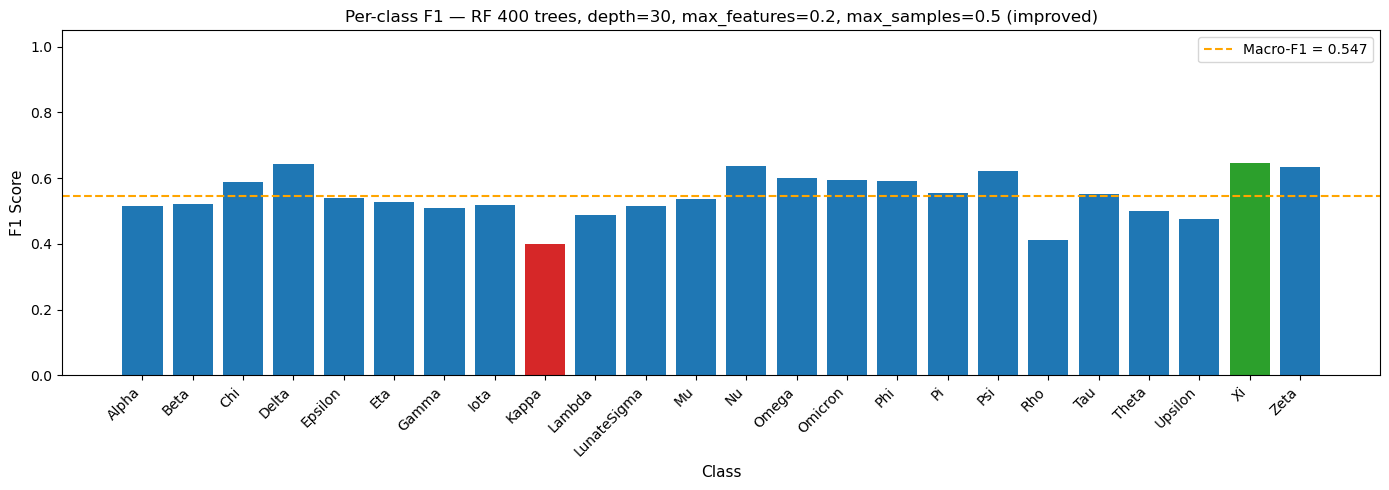

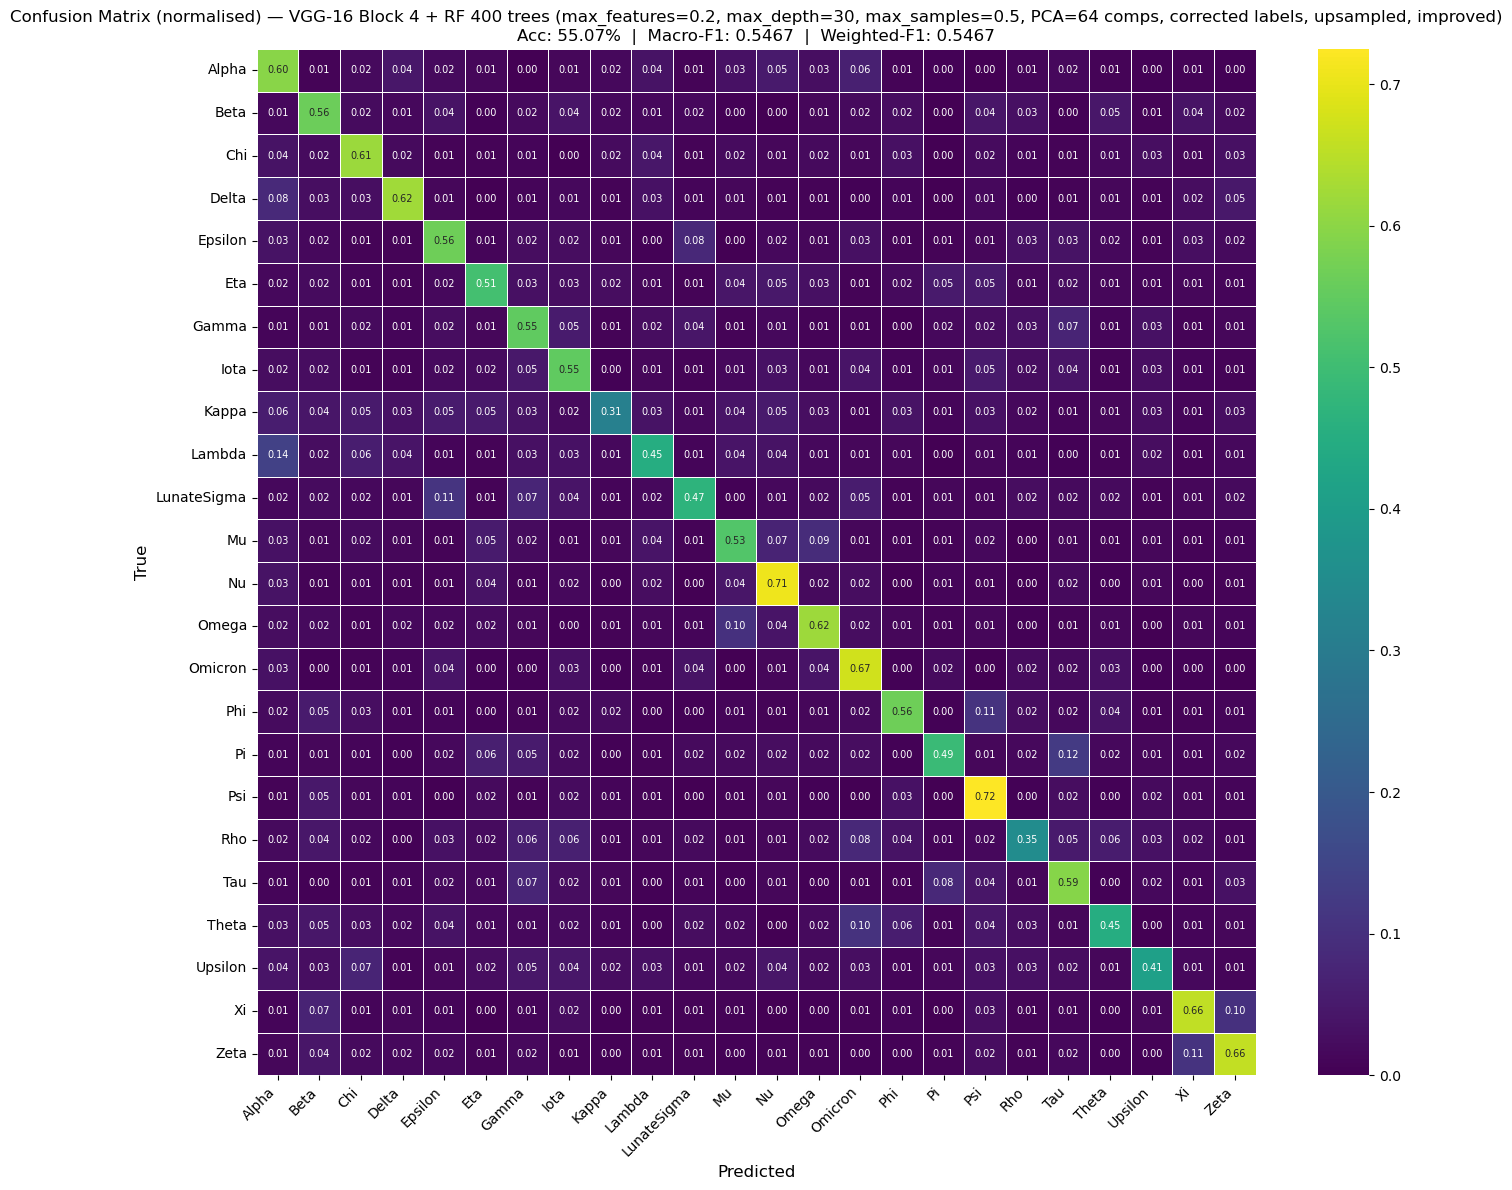

In [2]:
# rerun after labeling error (with strict PCA done) + optimizing v2

# AFTER APPLYING PCA




"""
Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Upsampled + PCA)
--------------------------------------------------------------------------------
Loads the already-split, already-scaled, already-PCA-reduced features saved by
prepare_features_pca.py and trains a plain RandomForestClassifier on them.
Class imbalance is handled upstream by upsampling the dataset itself, so no
balanced bootstrap / class_weight / SMOTE / BRF is needed here.

Run prepare_features_pca.py once first (or whenever you change the split,
test_size, random_state, or PCA variance threshold). This script can then be
re-run as many times as you like with different RF hyperparameters without
repeating the (fairly expensive) load/split/scale/PCA steps.

KEY CHANGES vs. previous run (51.61% accuracy):
  - max_depth    : 15   → 30    Deep trees are essential for PCA features; depth 15
                                was starving the trees of expressive power.
  - n_estimators : 200  → 400   More trees = more stable vote; still 2.5× fewer than
                                the original 1000 so training stays fast.
  - max_samples  : 0.3  → 0.5   30% bootstrap was too small; each tree saw too little
                                data and variance exploded. 50% restores diversity
                                while using the same RAM per tree as the old run.
  - max_features : sqrt → 0.2   "sqrt" of ~N_PCA components is often too few for
                                high-dimensional PCA space. 20% of components gives
                                each split a richer candidate set without being as
                                slow as the original 0.3 setting.
  - n_jobs       : 2    → 4     With depth capped at 30 and 400 trees (vs old
                                1000 × unlimited) total RAM is still lower than the
                                very first run, so we can safely restore 4 workers.
  - min_samples_leaf: 2 → 1     Leaf size 2 was preventing trees from perfectly
                                separating easy classes; 1 is standard for RF.

Outputs: model and a classification report. (scaler + PCA transformer were
already saved by prepare_features_pca.py — see the predict-later snippet
at the bottom.)
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib
import gc


# ── Settings ───────────────────────────────────────────────────────────────────

CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/UPSAMPLED_OUTPUT/upsampled_class_indices_3.json"
OUTPUT_DIR        = "C:/Users/niric/Desktop/classes/AI and ML/UPSAMPLED_OUTPUT"

X_TRAIN_FILE  = f"{OUTPUT_DIR}/X_train_pca_block4_upsampled_3.npy"
X_TEST_FILE   = f"{OUTPUT_DIR}/X_test_pca_block4_upsampled_3.npy"
Y_TRAIN_FILE  = f"{OUTPUT_DIR}/y_train_block4_upsampled_3.npy"
Y_TEST_FILE   = f"{OUTPUT_DIR}/y_test_block4_upsampled_3.npy"
PCA_META_FILE = f"{OUTPUT_DIR}/pca_meta_block4_upsampled_3.json"

if not os.path.exists(PCA_META_FILE):
    raise FileNotFoundError(
        f"Could not find {PCA_META_FILE}. Run prepare_features_pca.py first to "
        "generate the split/scaled/PCA-reduced features this script expects."
    )


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────
# Pull in the PCA preprocessing metadata produced by prepare_features_pca.py so
# this run's W&B config stays fully traceable back to that step too.

with open(PCA_META_FILE) as f:
    pca_meta = json.load(f)

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",   # plain RF — no balancing needed

    # ── n_estimators: 200 → 400 ───────────────────────────────────────────────
    # More trees reduce variance and improve vote stability, especially with
    # many classes. Still 2.5× fewer than the original 1000, so training is fast.
    "n_estimators":         400,

    # ── min_samples_leaf: 2 → 1 ───────────────────────────────────────────────
    # Leaf size of 2 prevented trees from reaching clean separations on easy
    # classes. Standard RF default of 1 recovers that expressiveness.
    "min_samples_leaf":     1,

    # ── max_features: "sqrt" → 0.2 ────────────────────────────────────────────
    # For PCA-reduced data, sqrt features per split is typically too few —
    # most components carry diffuse signal. 20% of components gives a richer
    # candidate set and improves split quality without the full cost of 0.3.
    "max_features":         0.2,

    # ── max_depth: 15 → 30 ────────────────────────────────────────────────────
    # Depth 15 was the main accuracy killer: PCA features need deep trees to
    # assemble fine-grained decision boundaries. Depth 30 roughly doubles
    # expressive capacity while still capping runaway growth (unlimited = None).
    # RAM impact is moderate because max_samples stays at 0.5.
    "max_depth":            30,

    # ── max_samples: 0.3 → 0.5 ────────────────────────────────────────────────
    # 30% bootstrap was too aggressive — each tree saw too little data, causing
    # high variance across the ensemble. 50% restores the standard RF balance
    # between diversity and coverage, and keeps per-tree RAM the same as a
    # previous run that achieved better accuracy.
    "max_samples":          0.5,

    # ── n_jobs: 2 → 4 ─────────────────────────────────────────────────────────
    # With trees capped at depth 30 and only 400 estimators (vs original 1000 ×
    # unlimited depth), total RAM stays lower than the very first run.
    # Restoring 4 workers cuts wall-clock time roughly in half.
    "n_jobs":               4,

    # ── Feature source (carried over from preprocessing) ──────────────────────
    "vgg16_block":            pca_meta.get("vgg16_block", "Unknown"),
    "feature_dim_original":   pca_meta.get("feature_dim", None),
    "pca_variance_threshold": pca_meta.get("pca_variance_threshold", "Strict/Fixed"),
    "pca_n_components":       pca_meta.get("pca_n_components", None),
    "pca_explained_variance": pca_meta.get("pca_explained_variance", None),

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "pre_applied_upsampling",  # balancing done before this script runs
    "smote_target":         None,                      # not used — no SMOTE/BRF here

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            pca_meta["test_size"],
    "split_random_state":   pca_meta["random_state"],   # used by the split, in prepare_features_pca.py
    "random_state":         42,                          # RF's own random_state (independent of the split's)
    "leakage_free_scaling": True,

    # ── Changes vs. previous run (51.61% acc) — for W&B run comparison ────────
    "opt_n_estimators_prev":  200,      # → 400  (more stable ensemble vote)
    "opt_max_depth_prev":     15,       # → 30   (main accuracy fix — trees were too shallow)
    "opt_max_features_prev":  "sqrt",   # → 0.2  (richer split candidates for PCA space)
    "opt_max_samples_prev":   0.3,      # → 0.5  (each tree sees more data, less variance)
    "opt_n_jobs_prev":        2,        # → 4    (safe to restore; total RAM still lower)
    "opt_min_samples_leaf_prev": 2,     # → 1    (standard default; recovers split precision)
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "RF_block4_upsampled_strict_pca_correcting_labeling_trees400_depth30_improved",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load prepared data ────────────────────────────────────────────────

print("Loading prepared (split + scaled + PCA-reduced) features...")

X_train = np.load(X_TRAIN_FILE)
X_test  = np.load(X_TEST_FILE)
y_train = np.load(Y_TRAIN_FILE)
y_test  = np.load(Y_TEST_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Train set : {X_train.shape[0]} images, {X_train.shape[1]} PCA components")
print(f"Test set  : {X_test.shape[0]} images")
print(f"Classes   : {len(class_names)}")


# ── Step 2: Train Random Forest ───────────────────────────────────────────────
# No class_weight, no balanced bootstrap, no sampling_strategy/replacement —
# upsampling already gave every class equal representation in the training
# data, so a standard RandomForestClassifier is sufficient here.

print("\nTraining Random Forest with improved config:")
print(f"  n_estimators     : {config.n_estimators}   (was 200  — more trees, stable vote)")
print(f"  max_depth        : {config.max_depth}          (was 15   — main accuracy fix)")
print(f"  max_features     : {config.max_features}      (was sqrt — richer split candidates)")
print(f"  max_samples      : {config.max_samples}       (was 0.3  — each tree sees more data)")
print(f"  n_jobs           : {config.n_jobs}             (was 2    — safe to restore 4 workers)")
print(f"  min_samples_leaf : {config.min_samples_leaf}             (was 2    — standard RF default)")

rf = RandomForestClassifier(
    n_estimators     = config.n_estimators,      # 400  (was 200)
    max_features     = config.max_features,      # 0.2  (was "sqrt")
    min_samples_leaf = config.min_samples_leaf,  # 1    (was 2)
    max_depth        = config.max_depth,         # 30   (was 15)
    max_samples      = config.max_samples,       # 0.5  (was 0.3)
    random_state     = config.random_state,
    n_jobs           = config.n_jobs             # 4    (was 2)
)

n_train_samples = X_train.shape[0]   # captured now since X_train is freed below

rf.fit(X_train, y_train)
print("Training done.")
print(f"  Trees built      : {len(rf.estimators_)}")
print(f"  Actual max depth : {max(e.get_depth() for e in rf.estimators_)} (capped at {config.max_depth})")

# X_train/y_train aren't needed again — only X_test/y_test are used from here on.
del X_train, y_train
gc.collect()


# ── Step 3: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]
best_class_idx   = per_class_f1.argmax()
best_class_name  = class_names[best_class_idx]
best_class_f1    = per_class_f1[best_class_idx]

print(f"\n── Results (improved RF: {config.n_estimators} trees, depth={config.max_depth}, "
      f"max_features={config.max_features}, max_samples={config.max_samples}) ──")
print(f"  Overall accuracy : {accuracy * 100:.2f}%")
print(f"  Macro-F1         : {macro_f1:.4f}")
print(f"  Weighted-F1      : {weighted_f1:.4f}")
print(f"  Best class       : {best_class_name} (F1 = {best_class_f1:.4f})")
print(f"  Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["final_best_class_f1"]    = best_class_f1
wandb.run.summary["final_best_class_name"]  = best_class_name
wandb.run.summary["n_train_samples"]        = n_train_samples
wandb.run.summary["n_test_samples"]         = X_test.shape[0]
wandb.run.summary["actual_max_depth"]       = max(e.get_depth() for e in rf.estimators_)
wandb.run.summary["n_classes"]              = len(class_names)


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})

# ── Per-class F1 bar chart → W&B ──────────────────────────────────────────────
fig_bar, ax_bar = plt.subplots(figsize=(14, 5))
bar_colors = ["#d62728" if s == worst_class_f1 else "#2ca02c" if s == best_class_f1
              else "#1f77b4" for s in per_class_f1]
ax_bar.bar(class_names, per_class_f1, color=bar_colors)
ax_bar.axhline(macro_f1, color="orange", linestyle="--", linewidth=1.5, label=f"Macro-F1 = {macro_f1:.3f}")
ax_bar.set_xlabel("Class", fontsize=11)
ax_bar.set_ylabel("F1 Score", fontsize=11)
ax_bar.set_title(
    f"Per-class F1 — RF {config.n_estimators} trees, depth={config.max_depth}, "
    f"max_features={config.max_features}, max_samples={config.max_samples} (improved)",
    fontsize=12
)
ax_bar.set_ylim(0, 1.05)
ax_bar.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
BAR_PATH = f"{OUTPUT_DIR}/per_class_f1_bar_block4_upsampled.png"
plt.savefig(BAR_PATH, dpi=150)
wandb.log({"per_class_f1_bar": wandb.Image(BAR_PATH)})
print(f"Saved: per_class_f1_bar_block4_upsampled.png to {OUTPUT_DIR}/")


# ── Step 4: Save model ────────────────────────────────────────────────────────
# scaler + PCA transformer were already saved by prepare_features_pca.py —
# only the trained model is new here.

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf, f"{OUTPUT_DIR}/random_forest_block4_upsampled.pkl")

print(f"Saved: random_forest_block4_upsampled.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + RF {config.n_estimators} trees "
    f"(max_features={config.max_features}, max_depth={config.max_depth}, "
    f"max_samples={config.max_samples}, PCA={config.pca_n_components} comps, "
    f"corrected labels, upsampled, improved)\n"
    f"Acc: {accuracy * 100:.2f}%  |  Macro-F1: {macro_f1:.4f}  |  Weighted-F1: {weighted_f1:.4f}",
    fontsize=12
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_upsampled.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_upsampled.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest_block4_upsampled.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block4_upsampled.pkl")
#   pca    = joblib.load("OUTPUT/pca_block4_upsampled.pkl")
#
#   feature_vector  = ...                          # your 512-d vector from the extractor
#   feature_scaled  = scaler.transform([feature_vector])
#   feature_reduced = pca.transform(feature_scaled)
#   prediction      = rf.predict(feature_reduced)
#   print(class_names[prediction[0]])